In [1]:
import pandas as pd
import json
import s3fs

# Lecture du JSON public depuis S3 (bucket ouvert, pas de credentials nécessaires)
fs = s3fs.S3FileSystem(anon=True)
path = "full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json"

with fs.open(path, "r", encoding="utf-8") as f:
    raw = json.load(f)

In [23]:
# raw peut être une liste d'objets {data:..., id:...} ou un dict {id: {data:...}}
if isinstance(raw, dict):
    records = [v.get("data", v) for v in raw.values()]
else:
    records = [r.get("data", r) for r in raw]

df = pd.json_normalize(records)
print(f"{len(df):,} jeux chargés")
print(df.columns.tolist()[:20])

55,691 jeux chargés
['appid', 'name', 'short_description', 'developer', 'publisher', 'genre', 'type', 'categories', 'owners', 'positive', 'negative', 'price', 'initialprice', 'discount', 'ccu', 'languages', 'release_date', 'required_age', 'website', 'header_image']


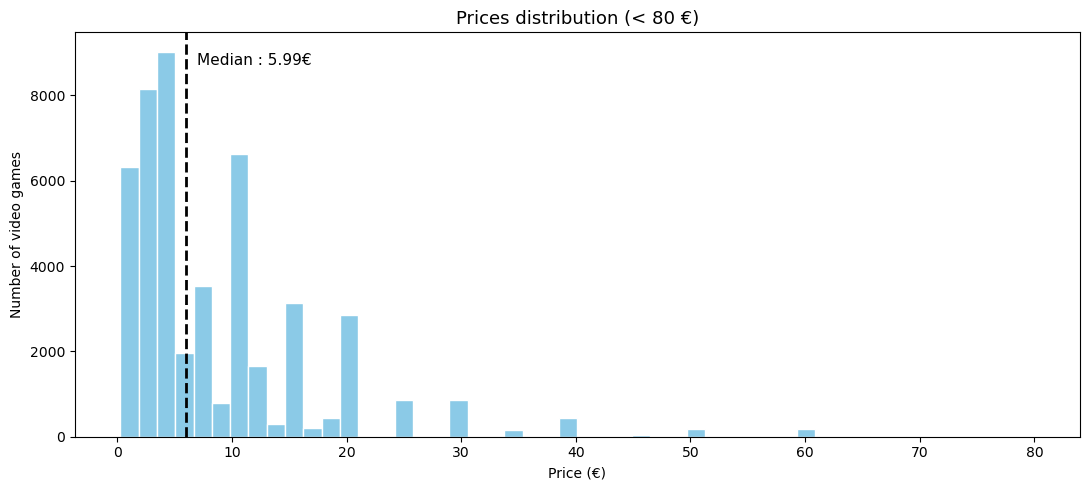

In [24]:
import matplotlib.pyplot as plt

# Prix : chaîne de centimes -> float en euros
df["price"] = pd.to_numeric(df["price"], errors="coerce") / 100

# Filtre : jeux payants sur la plage 0–100€
prices = df.loc[(df["price"] > 0) & (df["price"] <= 80), "price"]

mediane = prices.median()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(prices, bins=50, color="#8BCAE7", edgecolor="white")

ax.axvline(mediane, color="black", linestyle="--", linewidth=2)
ax.annotate(
    f"Median : {mediane:.2f}€",
    xy=(mediane, ax.get_ylim()[1] * 0.95),
    xytext=(8, 0), textcoords="offset points",
    color="black", fontsize=11, va="top",
)

ax.set_title(f"Prices distribution (< 80 €)", fontsize=13)
ax.set_xlabel("Price (€)")
ax.set_ylabel("Number of video games")

plt.tight_layout()
plt.show()

In [6]:
# --- Nettoyage des colonnes utiles avant export ---

# Prix : centimes -> euros (si pas déjà fait plus haut)
df["price"] = pd.to_numeric(df["price"], errors="coerce") / 100

# Conversions numériques tolérantes (équivalent try_cast)
for col in ["positive", "negative", "discount"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Année de sortie : extraction des 4 chiffres depuis la date
if "release_date" in df.columns:
    df["release_year"] = (
        df["release_date"].astype(str).str.extract(r"(\d{4})").astype("Int64")
    )

# Restriction d'âge : premier nombre trouvé
if "required_age" in df.columns:
    df["required_age"] = (
        df["required_age"].astype(str).str.extract(r"(\d+)").astype("Int64")
    )

# Ratio d'avis positifs
total = df["positive"].fillna(0) + df["negative"].fillna(0)
df["positive_ratio"] = (df["positive"] / total).where(total > 0).round(4)

# --- Sélection des colonnes à exporter ---
cols = [
    "appid", "name", "publisher", "developer",
    "price", "discount", "positive", "negative", "positive_ratio",
    "release_year", "required_age", "languages", "genre", "owners",
    "platforms.windows", "platforms.mac", "platforms.linux",
]
# On ne garde que les colonnes réellement présentes (le nom des colonnes platforms
# dépend de json_normalize : "platforms.windows" ou "platforms_windows")
cols = [c for c in cols if c in df.columns]

export = df[cols].copy()

# Renommage propre des colonnes plateformes si besoin
export = export.rename(columns={
    "platforms.windows": "on_windows",
    "platforms.mac": "on_mac",
    "platforms.linux": "on_linux",
})

# --- Sauvegarde CSV ---
export.to_csv("steam_games.csv", index=False, encoding="utf-8")
print(f"CSV écrit : steam_games.csv — {len(export):,} lignes, {len(export.columns)} colonnes")

CSV écrit : steam_games.csv — 55,691 lignes, 17 colonnes
